# Question 1: Understanding the Classification Problem

## Discussion

The aim of this task is to predict whether a small molecule is toxic or non-toxic to honey bees. The dataset is called ApisTox and contains information about pesticides and their toxicity to honey bees.

The input variables include the source of the chemical data the publication year the strongest toxicity type and information about whether the chemical is used as a herbicide fungicide insecticide or another agrochemical.

The output variable is 'label' . A value of 0 means non toxic and a value of 1 means toxic. Therefore this is a binary classification problem.

This task is useful because toxicity prediction can help with environmental and agricultural research. A wrong prediction can lead to a toxic chemical being treated as safe or a safe chemical being treated as toxic.

Because the two classes are no equal the model should not be judged only by accuracy. Other measures such as precision recall F1score and balanced accuracy should also be used.

In [6]:
import pandas as pd

data = pd.read_csv("dataset_final.csv")

print("Dataset shape:",data.shape)

print("\nTarget distribution:")
print(data["label"].value_counts())

print("\nTarget percentage:")
print(data["label"].value_counts(normalize=True)*100)

print("\nDataset columns:")
print(data.columns.tolist())

Dataset shape: (1035, 13)

Target distribution:
label
0    739
1    296
Name: count, dtype: int64

Target percentage:
label
0    71.400966
1    28.599034
Name: proportion, dtype: float64

Dataset columns:
['name', 'CID', 'CAS', 'SMILES', 'source', 'year', 'toxicity_type', 'herbicide', 'fungicide', 'insecticide', 'other_agrochemical', 'label', 'ppdb_level']


# Question 2: Data Exploration and Preparation

## Discussion

The ApisTox dataset was explored before building the machine learning models. The dataset size, data types, missing values and class distribution were checked.

The dataset contains both numerical and categorical features. Identifier columns and the `ppdb_level` column will not be used as model features. The `ppdb_level` column is closely related to the target label so using it could give the model information about the target.

The dataset does not have missing values. Therefore no missing value replacement is needed. The data will be split into training and testing sets using a 70:30 ratio.


### Data Quality Assessment

The dataset was checked to understand its size its data types missing values and class distribution. This helps us understand the data before preparing it for the machine learning models.

In [7]:
print("Dataset dimensions:")
print(data.shape)

print("\nData types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum())

print("\nClass distribution:")
print(data["label"].value_counts())

Dataset dimensions:
(1035, 13)

Data types:
name                  object
CID                    int64
CAS                   object
SMILES                object
source                object
year                   int64
toxicity_type         object
herbicide              int64
fungicide              int64
insecticide            int64
other_agrochemical     int64
label                  int64
ppdb_level             int64
dtype: object

Missing values:
name                  0
CID                   0
CAS                   0
SMILES                0
source                0
year                  0
toxicity_type         0
herbicide             0
fungicide             0
insecticide           0
other_agrochemical    0
label                 0
ppdb_level            0
dtype: int64

Class distribution:
label
0    739
1    296
Name: count, dtype: int64


### Result

The dataset contains 1035 rows and 13 columns. It has both categorical and numerical variables. There are no missing values in the dataset.

The target variable `label` has 739 records in class 0 and 296 records in class 1. This shows that the classes are not balanced. Therefore the class distribution should be considered when evaluating the machine learning models.

## Data Pre-processing

The dataset has no missing values so no missing value treatment is needed. The columns `name`, `CID`, `CAS` and `SMILES` are mainly used to identify or describe the chemical compounds. They were not used as model features.

The `ppdb_level` column was also removed because it is strongly related to the target label and may cause target leakage.

The remaining features contain categorical and numerical data. The data was split into training and testing sets using a 70:30 ratio. Onehot encoding was used for the categorical features and standard scaling was used for the numerical features.

In [8]:
# Select features and target
X = data.drop(["label","name","CID","CAS","SMILES","ppdb_level"],axis=1)

y = data["label"]

print("Selected features:")
print(X.columns.tolist())

Selected features:
['source', 'year', 'toxicity_type', 'herbicide', 'fungicide', 'insecticide', 'other_agrochemical']


In [10]:
# Identify categorical and numerical features

cat_features =X.select_dtypes(include="object").columns.tolist()
num_features =X.select_dtypes(exclude="object").columns.tolist()

print("Categorical features:")
print(cat_features)

print("\nNumerical features:")
print(num_features)

Categorical features:
['source', 'toxicity_type']

Numerical features:
['year', 'herbicide', 'fungicide', 'insecticide', 'other_agrochemical']


In [13]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

print("Training data:", Xtrain.shape)
print("Testing data:", Xtest.shape)

Training data: (724, 7)
Testing data: (311, 7)


In [14]:
# Encode categorical features

Xtrain =pd.get_dummies(Xtrain, columns=cat_features, drop_first=True)
Xtest =pd.get_dummies(Xtest, columns=cat_features, drop_first=True)

# Make both sets have the same columns
Xtest =Xtest.reindex(columns=Xtrain.columns, fill_value=0)

print("Training data after encoding:", Xtrain.shape)
print("Testing data after encoding:", Xtest.shape)

Training data after encoding: (724, 9)
Testing data after encoding: (311, 9)


In [15]:
#scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Xtrain_scaled = scaler.fit_transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)
print("Training data after scaling:", Xtrain_scaled.shape)
print("Testing data after scaling:", Xtest_scaled.shape)

Training data after scaling: (724, 9)
Testing data after scaling: (311, 9)


## Exploratory Analysis

The relationships between the features and the target were checked to find useful patterns in the data. Correlations were also checked to see which numerical features may be related to the target. This can help us understand which features may be useful for the machine learning models.

In [16]:
print("Average feature values for each class:")

print(
    data.groupby("label")[["year", "herbicide", "fungicide", "insecticide", "other_agrochemical"]].mean())

Average feature values for each class:
              year  herbicide  fungicide  insecticide  other_agrochemical
label                                                                    
0      1971.385656   0.441137   0.232747     0.083897            0.221922
1      1963.831081   0.094595   0.084459     0.557432            0.175676


In [17]:
# Check correlations between numerical features

corr = data[
    ["year", "herbicide", "fungicide","insecticide", "other_agrochemical", "label"]].corr()
print(corr.round(2))

                    year  herbicide  fungicide  insecticide  \
year                1.00       0.15       0.03        -0.08   
herbicide           0.15       1.00      -0.31        -0.37   
fungicide           0.03      -0.31       1.00        -0.22   
insecticide        -0.08      -0.37      -0.22         1.00   
other_agrochemical -0.14      -0.37      -0.25        -0.27   
label              -0.09      -0.33      -0.17         0.52   

                    other_agrochemical  label  
year                             -0.14  -0.09  
herbicide                        -0.37  -0.33  
fungicide                        -0.25  -0.17  
insecticide                      -0.27   0.52  
other_agrochemical                1.00  -0.05  
label                            -0.05   1.00  


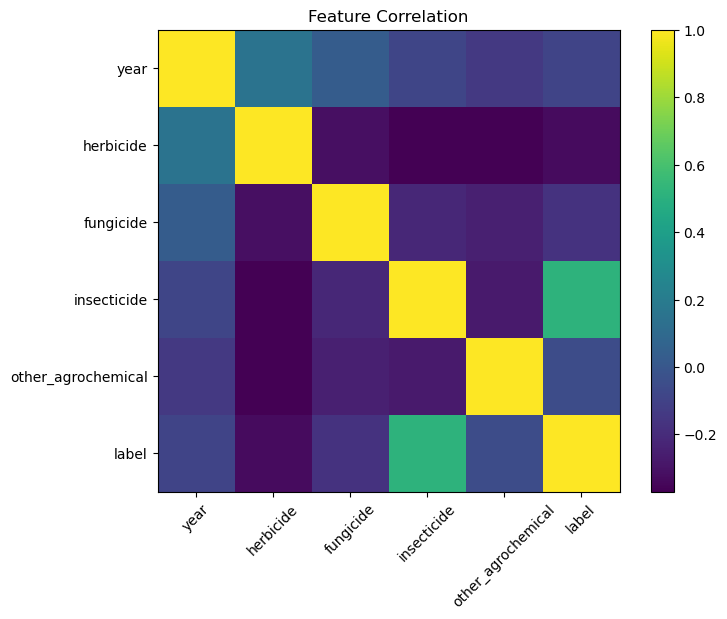

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.title("Feature Correlation")
plt.show()

### Result

The correlation results show that `insecticide` has the strongest relationship with the target with a correlation of 0.52. `herbicide` also has a noticeable relationship with the target with a value of -0.33.

The other features have weaker relationships with the target. The feature correlations are not very high. The largest correlation between two input features is about -0.37. This shows that there is some dependency between some features but there is no very strong redundancy.

# Question 3: Model Development and Selection

## Model 1: Logistic Regression

Logistic Regression was selected as the first model because it is a simple classification model and it is suitable for a binary target. It can also show how the input features are related to the chance of each class.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Logistic Regression model
log_model = LogisticRegression(max_iter=5000)

# Train model
log_model.fit(Xtrain_scaled, ytrain)

# Predictions
ypred_log = log_model.predict(Xtest_scaled)

print("Logistic Regression model trained.")

Logistic Regression model trained.


In [20]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

cv_scores = cross_val_score(log_model,Xtrain_scaled,ytrain,cv=cv,scoring="f1")

print("Cross-validation F1 scores:")
print(cv_scores)

print("\nMean CV F1-score:", cv_scores.mean())

Cross-validation F1 scores:
[0.70886076 0.61111111 0.63888889 0.64705882 0.58333333]

Mean CV F1-score: 0.6378505832712833


### Result

The Logistic Regression model was tested using 5-fold stratified cross-validation. The F1 scores were 0.709 0.611 0.639 0.647 and 0.583.

The mean F1 score was 0.638. This shows that the model had a reasonable performance across the different training folds. The scores were different between the folds so the model performance changes slightly with different parts of the data.

In [21]:
# Test different C values

C_values =[0.01,0.1,1,10,100]
log_results =[]

for c in C_values:
    model =LogisticRegression(C=c,max_iter=5000)
    
    scores =cross_val_score(model,Xtrain_scaled,ytrain,cv=cv,scoring="f1")
    
    log_results.append([c, scores.mean()])

log_results =pd.DataFrame(log_results,columns=["C", "Mean_F1"])
print(log_results)

best_c =log_results.loc[log_results["Mean_F1"].idxmax(),"C"]
print("\nBest C:", best_c)

        C   Mean_F1
0    0.01  0.633053
1    0.10  0.631433
2    1.00  0.637851
3   10.00  0.641580
4  100.00  0.641580

Best C: 10.0


### Result

Different C values were tested for Logistic Regression using 5-fold cross-validation. The best mean F1 score was 0.642 with C = 10. The same score was also found with C = 100.

C = 10 was selected because it gave the best result while using a smaller C value. The result shows that changing C had a small effect on the model performance.

In [23]:
# Train the final Logistic Regression model
from sklearn.metrics import f1_score
log_best =LogisticRegression(C=10,max_iter=5000)

log_best.fit(Xtrain_scaled, ytrain)

# Training and test predictions
train_pred_log =log_best.predict(Xtrain_scaled)
test_pred_log =log_best.predict(Xtest_scaled)

# Training and test F1
train_f1_log =f1_score(ytrain, train_pred_log)
test_f1_log = f1_score(ytest, test_pred_log)

print("Training F1-score:",train_f1_log)
print("Testing F1-score:",test_f1_log)

Training F1-score: 0.6353591160220995
Testing F1-score: 0.6265060240963856


### Result

The final Logistic Regression model used C = 10. The training F1 score was 0.635 and the testing F1 score was 0.627.

The two scores are close to each other. This shows that the model performs in a similar way on training and testing data. Therefore the model appears to generalise well and there is no strong sign of overfitting.

## Logistic Regression: Strengths and Weaknesses

Logistic Regression is simple and easy to understand. It is also useful for binary classification and gives a clear prediction for each class.

A weakness is that it works best when the relationship between the features and the target can be explained in a simple way. It may not work as well when the data has more complex patterns.

## Model 2: Support Vector Machine

Support Vector Machine was selected as the second model because it is useful for classification problems. It tries to find a boundary that separates the classes. SVM can also work well when the relationship between the features and the target is more complex.

One strength of SVM is that it can create a good boundary between classes. A weakness is that it can take more time to train than a simple model such as Logistic Regression.

In [24]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score

# Create SVM model
svm_model = SVC(kernel="linear",C=1)

# Train model
svm_model.fit(Xtrain_scaled,ytrain)

# Predictions
train_pred_svm=svm_model.predict(Xtrain_scaled)
test_pred_svm=svm_model.predict(Xtest_scaled)

# F1 scores
train_f1_svm =f1_score(ytrain,train_pred_svm)
test_f1_svm =f1_score(ytest,test_pred_svm)

print("Training F1-score:",train_f1_svm)
print("Testing F1-score:", test_f1_svm)

Training F1-score: 0.6751269035532995
Testing F1-score: 0.6666666666666666


### Result

The SVM model was trained using a linear kernel with C = 1. The training F1 score was 0.675 and the testing F1 score was 0.667.

The two scores are close to each other. This shows that the model performs in a similar way on training and testing data. Therefore the model appears to generalise well and there is no strong sign of overfitting.

In [25]:
# 5-fold crossvalidation for SVM

svm_cv =cross_val_score(svm_model,Xtrain_scaled,ytrain,cv=cv,scoring="f1")

print("Cross-validation F1 scores:")
print(svm_cv)

print("\nMean CV F1-score:",svm_cv.mean())

Cross-validation F1 scores:
[0.7        0.65822785 0.7        0.64864865 0.55882353]

Mean CV F1-score: 0.6531400052323357


In [26]:
# Test different C values for SVM

C_values =[0.01,0.1,1,10,100]
svm_results=[]

for c in C_values:
    model=SVC(kernel="linear",C=c)
    
    scores=cross_val_score(model,Xtrain_scaled,ytrain,cv=cv,scoring="f1")
    
    svm_results.append([c, scores.mean()])

svm_results=pd.DataFrame(svm_results,columns=["C","Mean_F1"])
print(svm_results)

best_svm_c =svm_results.loc[svm_results["Mean_F1"].idxmax(),"C"]
print("\nBest C:", best_svm_c)

        C   Mean_F1
0    0.01  0.633555
1    0.10  0.639298
2    1.00  0.653140
3   10.00  0.674709
4  100.00  0.674709

Best C: 10.0


### Result

Different C values were tested for the SVM using 5-fold cross-validation. The mean F1 score increased from 0.634 at C = 0.01 to 0.675 at C = 10.

The best mean F1 score was 0.675 with C = 10 and C = 100. C = 10 was selected because it gave the same score with a smaller value.

This shows that changing C improved the SVM performance on the validation data.

In [27]:
# Train the final SVM model

svm_best = SVC(kernel="linear",C=10)

svm_best.fit(Xtrain_scaled, ytrain)

# Predictions
train_pred_svm = svm_best.predict(Xtrain_scaled)
test_pred_svm = svm_best.predict(Xtest_scaled)

# F1 scores
train_f1_svm = f1_score(ytrain, train_pred_svm)
test_f1_svm = f1_score(ytest, test_pred_svm)

print("Training F1-score:", train_f1_svm)
print("Testing F1-score:", test_f1_svm)

Training F1-score: 0.6751269035532995
Testing F1-score: 0.6666666666666666


### Result

The final SVM model used a linear kernel with C = 10. The training F1 score was 0.675 and the testing F1 score was 0.667.

The two scores are very close. This shows that the model works in a similar way on training and testing data. Therefore the SVM appears to generalise well and there is no strong sign of overfitting.

In [28]:
# Compare the two models

print("Logistic Regression")
print("Testing F1-score:", test_f1_log)

print("\nSVM")
print("Testing F1-score:", test_f1_svm)

Logistic Regression
Testing F1-score: 0.6265060240963856

SVM
Testing F1-score: 0.6666666666666666


### Model Comparison Result

The Logistic Regression model had a testing F1 score of 0.627. The SVM model had a higher testing F1 score of 0.667.

The SVM performed better on the test data. This means the SVM was better at predicting the two classes in the current 70:30 split.

The SVM will be studied further when we deal with the class imbalance and test the models again.

# Question 4: Addressing Data Imbalance

## Discussion

The dataset has more samples in class 0 than class 1. This means the data is imbalanced. If the model focuses too much on the larger class it may not predict the smaller class well.

To deal with this problem `class_weight="balanced"` was used for both Logistic Regression and SVM. This gives more importance to the smaller class.

The models before and after balancing will be compared using accuracy precision recall and F1score. F1core and recall are important because they show how well the model can find the smaller class.

In [29]:
print("Class distribution:")
print(y.value_counts())

print("\nClass percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Class distribution:
label
0    739
1    296
Name: count, dtype: int64

Class percentage:
label
0    71.4
1    28.6
Name: proportion, dtype: float64


### Result

The dataset is imbalanced because class 0 contains 71.4% of the records while class 1 contains 28.6%. The larger class has much more data than the smaller class. Therefore the model may focus more on class 0. Class weighting will be used to give more importance to class 1.

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Balanced Logistic Regression

log_balanced = LogisticRegression(C=10,class_weight="balanced",max_iter=5000)

log_balanced.fit(Xtrain_scaled, ytrain)

pred_log_balanced = log_balanced.predict(Xtest_scaled)

print("Balanced Logistic Regression")
print("Accuracy:", accuracy_score(ytest, pred_log_balanced))
print("Precision:",precision_score(ytest, pred_log_balanced))
print("Recall:",recall_score(ytest, pred_log_balanced))
print("F1-score:",f1_score(ytest, pred_log_balanced))

Balanced Logistic Regression
Accuracy: 0.797427652733119
Precision: 0.63
Recall: 0.7078651685393258
F1-score: 0.6666666666666666


### Result

The balanced Logistic Regression model achieved an accuracy of 79.74%. The precision was 63.00% and the recall was 70.79%. The F1 score was 66.67%.

The balanced model gives more attention to class 1. This can help the model find more samples from the smaller class. However the accuracy became lower compared with the original model.